In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from typing import List
from pathlib import Path
from typing import Any
from datetime import datetime
from pandas import DataFrame
from pandas import Series

# Config
pd.options.display.float_format = '{:.3f}'.format

# Paths
csv_file_path: str = "csv_files"
csv_file_pattern: str = "mean_reversion_*.csv"
# csv_file_merged: str = csv_file_path + "/merged_mean_reversion.csv"

# Merge CSVs files
csv_df_list = []
for csv_path in Path(csv_file_path).glob(csv_file_pattern):
    csv_df = pd.read_csv(csv_path, sep = ";", encoding = 'utf-16')
    csv_df_list.append(csv_df)

df_raw: DataFrame = pd.concat(csv_df_list, ignore_index=True)
df_raw.drop_duplicates(inplace=True)
# csv_df_merged.to_csv(csv_file_merged, sep=";", index=False)

df_raw

,symbol,timeframe,setup_time,session,current_block_pivot_strength,current_block_type,current_block_start_price,current_block_end_price,bb_period,bb_upper_band,...,rsi_value,rsi_extension,entry_date,entry_delay,entry_type,entry_price,entry_level,entry_sl,entry_rr_max,entry_hit_sl
0,XAUUSD,1,2026.01.02 20:29:00,NEW_YORK,5,BULLISH,4318.835,4329.478,10,4329.937,...,70.415,True,2026.01.02 20:31:00,1,ORDER_TYPE_SELL,4327.532,18.284,4329.478,1.127,True
1,XAUUSD,1,2026.01.02 21:00:00,ALL,5,BULLISH,4326.417,4331.932,10,4332.051,...,64.137,False,2026.01.02 21:02:00,1,ORDER_TYPE_SELL,4329.863,37.516,4331.932,1.318,True
2,XAUUSD,1,2026.01.04 23:15:00,ALL,5,BULLISH,4327.348,4372.719,10,4383.173,...,93.672,True,2026.01.04 23:17:00,1,ORDER_TYPE_SELL,4366.517,13.670,4372.719,1.947,True
3,XAUUSD,1,2026.01.04 23:57:00,ALL,5,BULLISH,4354.441,4376.010,10,4377.727,...,68.642,False,2026.01.04 23:59:00,1,ORDER_TYPE_SELL,4374.196,8.410,4376.010,2.154,True
4,XAUUSD,1,2026.01.05 05:31:00,TOKYO,5,BULLISH,4407.115,4414.615,10,4413.877,...,62.164,False,2026.01.05 05:33:00,1,ORDER_TYPE_SELL,4410.691,52.320,4414.615,2.385,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211075,XAUUSD,1,2026.07.03 08:05:00,LONDON,5,BULLISH,4174.699,4185.873,20,4185.024,...,71.674,True,2026.07.03 08:11:00,5,ORDER_TYPE_SELL,4182.022,34.464,4185.873,0.302,True
211076,XAUUSD,1,2026.07.03 09:38:00,LONDON,5,BEARISH,4180.515,4168.353,20,4177.695,...,42.229,False,2026.07.03 09:44:00,5,ORDER_TYPE_BUY,4171.246,23.787,4168.353,5.228,False
211077,XAUUSD,1,2026.07.03 11:16:00,LONDON,5,BULLISH,4175.448,4185.111,20,4184.208,...,85.839,True,2026.07.03 11:22:00,5,ORDER_TYPE_SELL,4183.167,20.118,4185.111,0.303,True
211078,XAUUSD,1,2026.07.03 12:27:00,NEW_YORK,5,BEARISH,4183.478,4172.183,20,4182.341,...,27.276,True,2026.07.03 12:33:00,5,ORDER_TYPE_BUY,4174.508,20.584,4172.183,2.069,True


In [3]:
# Values
min_rr: float = 0.5

# Filter
df_raw = df_raw[
    ~(
        (df_raw["entry_rr_max"] < min_rr) &
        (df_raw["entry_hit_sl"] == False)
    )
]

# Data columns
df_raw["data_trade_won"] = df_raw["entry_rr_max"] >= min_rr

df_raw["data_rr_dist"] = pd.cut(
    df_raw["entry_rr_max"],
    bins=[0, 0.5, 1.0, 2.0, 3.0, np.inf],
    labels=[
        "< 0.5",
        "0.5 - 1.0",
        "1.0 - 2.0",
        "2.0 - 3.0",
        "> 3.0"
    ],
    include_lowest=True
)

df_raw["data_level_dist"] = pd.cut(
    df_raw["entry_level"],
    bins=[0, 10, 20, 30, 40, 50, 75, np.inf],
    labels=[
        "< 10%",
        "10% - 20%",
        "20% - 30%",
        "30% - 40%",
        "40% - 50%",
        "50% - 75%",
        "> 75%"
    ],
    include_lowest=True
)

'''

df_raw["data_rsi_dist"] = pd.cut(
    df_raw["rsi_value"],
    bins=[0, 10, 15, 20, 25, 30, 70, 75, 80, 85, 90, np.inf],
    labels=[
        "< 10",
        "10 - 15",
        "15 - 20",
        "20 - 25",
        "25 - 30",
        "30 - 70",
        "70 - 75",
        "75 - 80",
        "80 - 85",
        "85 - 90",
        "> 90"
    ],
    include_lowest=True
)


'''


'''

rr_labels = {
    "< 0.5":        "Dead",
    "0.5 - 1.0":    "Weak",
    "1.0 - 2.0":    "Acceptable",
    "2.0 - 3.0":    "Good",
    "> 3.0":        "Excellent",
}

df_raw["data_rr_label"] = df_raw["data_rr_dist"].map(rr_labels)


# Functions
def group_by_data_win(df_base: DataFrame, column_names: List[str]) -> DataFrame:
    column_names.append("data_win")

    result: DataFrame = df_base.groupby(column_names).size().unstack(fill_value=0)
    result.rename(inplace=True, columns = { False: "losses", True: "wins"})

    result["total"] = (result["losses"] + result["wins"])
    result["win_rate"] = ((result["wins"] / result["total"]) * 100)

    return result
'''

df_raw

,symbol,timeframe,setup_time,session,current_block_pivot_strength,current_block_type,current_block_start_price,current_block_end_price,bb_period,bb_upper_band,...,entry_delay,entry_type,entry_price,entry_level,entry_sl,entry_rr_max,entry_hit_sl,data_trade_won,data_rr_dist,data_level_dist
0,XAUUSD,1,2026.01.02 20:29:00,NEW_YORK,5,BULLISH,4318.835,4329.478,10,4329.937,...,1,ORDER_TYPE_SELL,4327.532,18.284,4329.478,1.127,True,True,1.0 - 2.0,10% - 20%
1,XAUUSD,1,2026.01.02 21:00:00,ALL,5,BULLISH,4326.417,4331.932,10,4332.051,...,1,ORDER_TYPE_SELL,4329.863,37.516,4331.932,1.318,True,True,1.0 - 2.0,30% - 40%
2,XAUUSD,1,2026.01.04 23:15:00,ALL,5,BULLISH,4327.348,4372.719,10,4383.173,...,1,ORDER_TYPE_SELL,4366.517,13.670,4372.719,1.947,True,True,1.0 - 2.0,10% - 20%
3,XAUUSD,1,2026.01.04 23:57:00,ALL,5,BULLISH,4354.441,4376.010,10,4377.727,...,1,ORDER_TYPE_SELL,4374.196,8.410,4376.010,2.154,True,True,2.0 - 3.0,< 10%
4,XAUUSD,1,2026.01.05 05:31:00,TOKYO,5,BULLISH,4407.115,4414.615,10,4413.877,...,1,ORDER_TYPE_SELL,4410.691,52.320,4414.615,2.385,True,True,2.0 - 3.0,50% - 75%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211075,XAUUSD,1,2026.07.03 08:05:00,LONDON,5,BULLISH,4174.699,4185.873,20,4185.024,...,5,ORDER_TYPE_SELL,4182.022,34.464,4185.873,0.302,True,False,< 0.5,30% - 40%
211076,XAUUSD,1,2026.07.03 09:38:00,LONDON,5,BEARISH,4180.515,4168.353,20,4177.695,...,5,ORDER_TYPE_BUY,4171.246,23.787,4168.353,5.228,False,True,> 3.0,20% - 30%
211077,XAUUSD,1,2026.07.03 11:16:00,LONDON,5,BULLISH,4175.448,4185.111,20,4184.208,...,5,ORDER_TYPE_SELL,4183.167,20.118,4185.111,0.303,True,False,< 0.5,20% - 30%
211078,XAUUSD,1,2026.07.03 12:27:00,NEW_YORK,5,BEARISH,4183.478,4172.183,20,4182.341,...,5,ORDER_TYPE_BUY,4174.508,20.584,4172.183,2.069,True,True,2.0 - 3.0,20% - 30%


In [4]:
# Bollinger & RSI
df_bb_ext = (df_raw["bb_extension"] == True)
df_rsi_ext = (df_raw["rsi_extension"] == True)
df_base = df_raw[(df_bb_ext & df_rsi_ext)]

df_filter = ["bb_period", "rsi_ma_period", "data_rr_dist"]
df_base = df_base[df_filter]

df_rr_dist = (
    df_base
    .groupby(["bb_period", "rsi_ma_period"])["data_rr_dist"]
    .value_counts(normalize=True)
    .mul(100)
    .unstack(fill_value=0)
)

df_rr_dist_trades = (
    df_base
    .groupby(["bb_period", "rsi_ma_period"])
    .size()
    .rename("trades")
)

df_summary = df_rr_dist.join(df_rr_dist_trades)
df_summary

# Selected: BB = 20 & RSI = 7

< 0.5  0.5 - 1.0  1.0 - 2.0  2.0 - 3.0  > 3.0  trades
bb_period rsi_ma_period                                                       
10        5             17.728     15.811     21.490     13.566 31.404    8241
          7             17.553     15.742     21.588     13.633 31.484    7731
          9             17.827     15.984     21.819     13.732 30.638    6838
          14            17.825     16.173     22.643     14.751 28.607    4359
15        5             17.742     15.875     20.890     13.507 31.985    9373
          7             17.730     15.742     20.829     13.541 32.158    8906
          9             18.001     15.923     21.168     13.656 31.252    7894
          14            17.689     16.101     21.680     14.572 29.958    5037
20        5             17.748     15.529     20.901     13.550 32.272   10052
          7             17.785     15.559     20.867     13.448 32.341    9570
          9             18.032     15.675     21.183     13.562 31.548    8568
          14            17.761     15.840     21.932     14.286 30.181    5467

In [5]:
# Entry level
df_bb_value = (df_raw["bb_period"] == 20)
df_rsi_ext = (df_raw["rsi_ma_period"] == 7)
df_base = df_raw[(df_bb_value & df_rsi_ext)]

df_filter = ["data_trade_won", "data_level_dist"]
df_base = df_base[df_filter].groupby(df_filter).value_counts()

df_base

# Selected: < 30%

data_trade_won  data_level_dist
False           < 10%                42
                10% - 20%           386
                20% - 30%           736
                30% - 40%           747
                40% - 50%           542
                50% - 75%           634
                > 75%               261
True            < 10%              1028
                10% - 20%          3582
                20% - 30%          3628
                30% - 40%          2524
                40% - 50%          1460
                50% - 75%          1425
                > 75%               536
Name: count, dtype: int64

In [6]:
# Session
df_bb_value = (df_raw["bb_period"] == 20)
df_rsi_ext = (df_raw["rsi_ma_period"] == 7)
df_level = (df_raw["entry_level"] < 30)
df_base = df_raw[(df_bb_value & df_rsi_ext & df_level)]

df_base = df_base[["session", "data_trade_won"]].groupby(["session", "data_trade_won"]).value_counts()
df_base

# Selected: NEW_YORK

session   data_trade_won
ALL       False              133
          True               783
LONDON    False              236
          True              1661
NEW_YORK  False              410
          True              3170
TOKYO     False              384
          True              2622
Name: count, dtype: int64

In [7]:
# Delay
df_bb_value = (df_raw["bb_period"] == 20)
df_rsi_ext = (df_raw["rsi_ma_period"] == 7)
df_level = (df_raw["entry_level"] < 30)
df_session = (df_raw["session"] == "NEW_YORK")

df_base = df_raw[(df_bb_value & df_rsi_ext & df_level & df_session)]

# Métricas generales
summary = (
    df_base
    .groupby("entry_delay")
    .agg(
        trades=("data_trade_won", "count"),
        wins=("data_trade_won", "sum"),
        winrate=("data_trade_won", "mean")
    )
)

summary["winrate"] *= 100

# Distribución de RR
rr_dist = (
    df_base
    .groupby("entry_delay")["data_rr_dist"]
    .value_counts(normalize=True)
    .mul(100)
    .unstack(fill_value=0)
)

# Tabla final
summary = summary.join(rr_dist)

summary

# Selected: Delay 1

,trades,wins,winrate,< 0.5,0.5 - 1.0,1.0 - 2.0,2.0 - 3.0,> 3.0
entry_delay,,,,,,,,
1,963,941,97.715,2.285,9.657,19.834,14.642,53.583
2,779,729,93.582,6.418,14.249,20.026,16.303,43.004
3,663,587,88.537,11.463,14.932,20.965,13.725,38.914
4,612,502,82.026,17.974,16.013,18.954,11.765,35.294
5,563,411,73.002,26.998,15.808,17.584,10.835,28.774


In [18]:
bins = [0, 0.5, 1, 2, 3, 5, 10, 20]

df_base["rr_bucket"] = pd.cut(
    df_base["entry_rr_max"],
    bins=bins
)

rr_mode = (
    df_base
    ["rr_bucket"]
    .agg(lambda s: s.mode().iloc[0])
)

print(rr_mode)

(1.0, 2.0]


In [8]:
# Check Win Rate
df_win_rate_base = df_raw[df_raw["current_block_pivot_strength"] == df_raw["entry_delay"]]
df_win_rate_filter = ["timeframe", "data_trade_won"]
df_win_rate_values = df_win_rate_base[df_win_rate_filter].groupby(df_win_rate_filter).value_counts()
print(df_win_rate_values)

timeframe  data_trade_won
1          False             12612
           True              29436
Name: count, dtype: int64


In [9]:
# Check Rate Delay
df_rate_delay_base = df_raw[
    (df_raw["timeframe"] == 1) &
    (df_raw["session"] == "NEW_YORK") &
    (df_raw["current_block_pivot_strength"] == 5)
]

df_tf: DataFrame = pd.crosstab(
        df_rate_delay_base["entry_delay"],
        df_rate_delay_base["data_rr_dist"],
        normalize="index"
    ).mul(100).round(2)

df_tf.insert(0, "Trades", df_raw.groupby("entry_delay").size())
df_tf.insert(1, "WinRate", (100 - df_tf["< 0.5"]))

df_tf

data_rr_dist,Trades,WinRate,< 0.5,0.5 - 1.0,1.0 - 2.0,2.0 - 3.0,> 3.0
entry_delay,,,,,,,
1,42132,93.960,6.040,11.720,21.790,14.400,46.040
2,42096,87.600,12.400,16.210,22.330,15.380,33.680
3,42084,80.700,19.300,17.730,20.420,13.690,28.870
4,42012,76.690,23.310,17.920,19.040,13.040,26.690
5,42048,70.730,29.270,17.370,19.840,11.080,22.460


In [10]:
# Compare Timeframes
df_tf: DataFrame = pd.crosstab(
        df_raw["timeframe"],
        df_raw["data_rr_dist"],
        normalize="index"
    ).mul(100).round(2)

df_tf.insert(0, "Trades", df_raw.groupby("timeframe").size())
df_tf.insert(1, "WinRate", (100 - df_tf["< 0.5"]))

df_tf

# Outcome: M1 is selected
# It the largest sample and similar WinRate
# It has the largest probability of >= 2R

data_rr_dist,Trades,WinRate,< 0.5,0.5 - 1.0,1.0 - 2.0,2.0 - 3.0,> 3.0
timeframe,,,,,,,
1,210372,80.880,19.120,15.900,20.590,13.080,31.310


In [11]:
# Select timeframe
df_tf: DataFrame = df_raw[df_raw["timeframe"] == 1]

# Compare Sessions
df_ss = pd.crosstab(
        df_tf["session"],
        df_tf["data_rr_dist"],
        normalize="index"
    ).mul(100).round(2)

df_ss.insert(0, "Trades", df_tf.groupby("session").size())
df_ss.insert(1, "WinRate", (100 - df_ss["< 0.5"]))

df_ss

# Outcome: There is not a remarkable session (all have similar values)
# Could be NewYork as default, because it has more trades

data_rr_dist,Trades,WinRate,< 0.5,0.5 - 1.0,1.0 - 2.0,2.0 - 3.0,> 3.0
session,,,,,,,
ALL,19452,81.370,18.630,15.480,20.230,13.570,32.080
LONDON,45996,79.960,20.040,15.340,20.740,13.100,30.790
NEW_YORK,80232,81.950,18.050,16.180,20.690,13.520,31.560
TOKYO,64692,80.060,19.940,16.060,20.480,12.370,31.140


In [12]:
# Selected
selected_tf: int = 1
selected_ss: str = "NEW_YORK"

df_selected = df_raw[
    (df_raw["timeframe"] == selected_tf) &
    (df_raw["session"] == selected_ss)
]

# Comapre Pivot Strength
df_ps = pd.crosstab(
        df_selected["current_block_pivot_strength"],
        df_selected["data_rr_dist"],
        normalize="index"
    ).mul(100).round(2)

df_ps.insert(0, "Trades", df_selected.groupby("current_block_pivot_strength").size())
df_ps.insert(1, "WinRate", 100 - df_ps["< 0.5"])

df_ps

# Outcome: The bigger pivot the smaller WinRate
# pivot_strength = 1, looks like the best performance, its gonna be contrasted to confirm

data_rr_dist,Trades,WinRate,< 0.5,0.5 - 1.0,1.0 - 2.0,2.0 - 3.0,> 3.0
current_block_pivot_strength,,,,,,,
5,80232,81.950,18.050,16.180,20.690,13.520,31.560


In [13]:
# Selected
selected_tf: int = 1
selected_ss: str = "NEW_YORK"

df_selected = df_raw[
    (df_raw["timeframe"] == selected_tf) &
    (df_raw["session"] == selected_ss)
]

# Compare Pivot & Bollinger
df_ps_bb = (
    pd.crosstab(
        [
            df_selected["current_block_pivot_strength"],
            df_selected["bb_period"]
        ],
        df_selected["data_rr_dist"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

# Trades
df_ps_bb.insert(
    0,
    "Trades",
    df_selected.groupby(
        ["current_block_pivot_strength", "bb_period"]
    ).size()
)

# WinRate
df_ps_bb.insert(
    1,
    "WinRate",
    100 - df_ps_bb["< 0.5"]
)

df_ps_bb

# Outcome: Bollinger value doesn't affect WinRate like Pivot does
# Across bollinger values in the same pivot, the WinRate is pretty similar
# Different Pivot values does generate different WinRate values
# Pivot = 1 is selected, bollinger will be contrasted with RSI in order to define a value

data_rr_dist                            Trades  WinRate  < 0.5  0.5 - 1.0  \
current_block_pivot_strength bb_period                                      
5                            10          26744   81.950 18.050     16.180   
                             15          26744   81.950 18.050     16.180   
                             20          26744   81.950 18.050     16.180   

data_rr_dist                            1.0 - 2.0  2.0 - 3.0  > 3.0  
current_block_pivot_strength bb_period                               
5                            10            20.690     13.520 31.560  
                             15            20.690     13.520 31.560  
                             20            20.690     13.520 31.560

In [14]:
# Selected
selected_tf: int = 1
selected_ss: str = "NEW_YORK"
selected_ps: int = 1

df_selected = df_raw[
    (df_raw["timeframe"] == selected_tf) &
    (df_raw["session"] == selected_ss) &
    (df_raw["current_block_pivot_strength"] == selected_ps)
]

# Compare Bollinger & RSI
df_bb_rsi = (
    pd.crosstab(
        [
            df_selected["bb_period"],
            df_selected["rsi_ma_period"]
        ],
        df_selected["data_rr_dist"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

# Trades
df_bb_rsi.insert(
    0,
    "Trades",
    df_selected.groupby(
        ["bb_period", "rsi_ma_period"]
    ).size()
)

# WinRate
df_bb_rsi.insert(
    1,
    "WinRate",
    100 - df_bb_rsi["< 0.5"]
)

df_bb_rsi

# Outcome: Looks like RSI 14 improves the WinRate
# Bollinger 10 seems to be a good parthership

KeyError: '< 0.5'

In [ ]:
# Selected
selected_tf: int = 1
selected_ss: str = "NEW_YORK"
selected_ps: int = 1
selected_bb: int = 10
selected_rsi: int = 14

df_selected = df_raw[
    (df_raw["timeframe"] == selected_tf) &
    (df_raw["session"] == selected_ss) &
    (df_raw["current_block_pivot_strength"] == selected_ps) &
    (df_raw["bb_period"] == selected_bb) &
    (df_raw["rsi_ma_period"] == selected_rsi)
]

# Compare entry level
df_entry = (
    pd.crosstab(
        df_selected["data_level_dist"],
        df_selected["data_rr_dist"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

df_entry.insert(
    0,
    "Trades",
    df_selected.groupby("data_level_dist").size()
)

df_entry.insert(
    1,
    "WinRate",
    100 - df_entry["< 0.5"]
)

df_entry

# Outcome: Level < 30% increases the trades oportunities keeping the WinRate

data_rr_dist,Trades,WinRate,< 0.5,0.5 - 1.0,1.0 - 2.0,2.0 - 3.0,> 3.0
data_level_dist,,,,,,,
< 20%,142,78.170,21.830,11.970,19.010,11.270,35.920
20% - 40%,347,74.640,25.360,17.580,23.630,20.170,13.260
40% - 60%,133,76.690,23.310,27.070,48.120,0.750,0.750
60% - 80%,28,75.000,25.000,75.000,0.000,0.000,0.000
> 80%,18,22.220,77.780,22.220,0.000,0.000,0.000


In [ ]:
def analyze_entry_cut(df, cutoff):
    col = df["entry_level"] < cutoff

    labels = col.map({
        True: f"<{cutoff}%",
        False: f">={cutoff}%"
    })

    trades = labels.value_counts()

    result = (
        pd.crosstab(
            col.map({True: f"<{cutoff}%", False: f">={cutoff}%"}),
            df["data_rr_dist"],
            normalize="index"
        )
        .mul(100)
        .round(2)
    )

    result.insert(
       0,
        "Trades",
        trades.reindex(result.index)
    )
    result.insert(1, "WinRate", 100 - result["< 0.5"])

    return result

print(analyze_entry_cut(df_selected, 20))
print(analyze_entry_cut(df_selected, 30))
print(analyze_entry_cut(df_selected, 40))

data_rr_dist  Trades  WinRate  < 0.5  0.5 - 1.0  1.0 - 2.0  2.0 - 3.0  > 3.0
entry_level                                                                 
<20%             142   78.170 21.830     11.970     19.010     11.270 35.920
>=20%            526   73.380 26.620     23.190     27.760     13.500  8.940
data_rr_dist  Trades  WinRate  < 0.5  0.5 - 1.0  1.0 - 2.0  2.0 - 3.0  > 3.0
entry_level                                                                 
<30%             348   77.300 22.700     15.230     20.110     14.080 27.870
>=30%            320   71.250 28.750     26.880     32.190     11.880  0.310
data_rr_dist  Trades  WinRate  < 0.5  0.5 - 1.0  1.0 - 2.0  2.0 - 3.0  > 3.0
entry_level                                                                 
<40%             489   75.660 24.340     15.950     22.290     17.590 19.840
>=40%            179   70.950 29.050     34.080     35.750      0.560  0.560


In [ ]:
# Initial config
selected_tf: int = 1
selected_ss: str = "NEW_YORK"
selected_ps: int = 1
selected_bb: int = 10
selected_rsi: int = 14
selected_lvl: int = 30

df_selected = df_raw[
    (df_raw["timeframe"] == selected_tf) &
    (df_raw["session"] == selected_ss) &
    (df_raw["current_block_pivot_strength"] == selected_ps) &
    (df_raw["bb_period"] == selected_bb) &
    (df_raw["rsi_ma_period"] == selected_rsi) &
    (df_raw["entry_level"] < selected_lvl)
]

df_result = (
    pd.crosstab(
        index=["Selected Setup"],
        columns=df_selected["data_rr_dist"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

df_result.insert(0, "Trades", len(df_selected))
df_result.insert(1, "WinRate", 100 - df_result["< 0.5"])

df_result

data_rr_dist,Trades,WinRate,< 0.5,0.5 - 1.0,1.0 - 2.0,2.0 - 3.0,> 3.0
row_0,,,,,,,
Selected Setup,243,76.950,23.050,13.170,19.340,9.470,34.980


In [ ]:
# Same block type ?
df_same_type_values: Series[Any] = df_raw.groupby("same_block_type").aggregate("outcome_win")
df_same_type_frame: DataFrame = df_same_type_values.size().unstack(fill_value=0)
print(df_same_type_frame)

df_same_type_frame.plot(kind="bar", color=["red", "green"])

plt.title("Wins vs Losses")
plt.xlabel("Same Block Type")
plt.ylabel("Trades")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Based on results, same type doesn't affect results, it keeps same winrate regardless block types

'''

# df_win_rate: DataFrame = df_raw.groupby(["timeframe", "session", "data_win"]).size().unstack(fill_value=0)
# df_win_rate.rename(inplace=True, columns={
#     False: "losses",
#    True: "wins"
#})
#df_win_rate["trades"] = (df_win_rate["losses"] + df_win_rate["wins"])
#df_win_rate["win_rate"] = ((df_win_rate["wins"] / df_win_rate["trades"]) * 100)
#df_win_rate[["losses", "wins"]].plot(kind="bar", color=["red", "green"], rot=90)
#print(df_win_rate)
'''

KeyError: 'same_block_type'

                  SL   TP
entry_level_pct          
<30%             124  538
30%-60%          245  534
60%-90%           36   47
>=90%              1    0


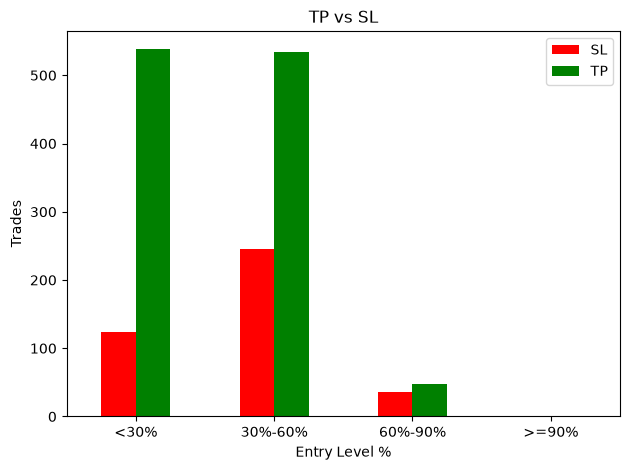

In [ ]:
# Entry level
entry_level_frame: DataFrame = df_raw.groupby(["entry_level_pct", "outcome_win"]).size().unstack(fill_value=0)
entry_level_frame.columns = ["SL", "TP"]
entry_level_frame.plot(kind="bar", color=["red", "green"])
print(entry_level_frame)

plt.title("TP vs SL")
plt.xlabel("Entry Level %")
plt.ylabel("Trades")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Based on results, entry level percentage < 30% gives good results without additional SLs

              SL   TP
session              
AFTER_HOURS   25   92
LONDON        87  251
NEW_YORK     133  389
TOKYO        161  387


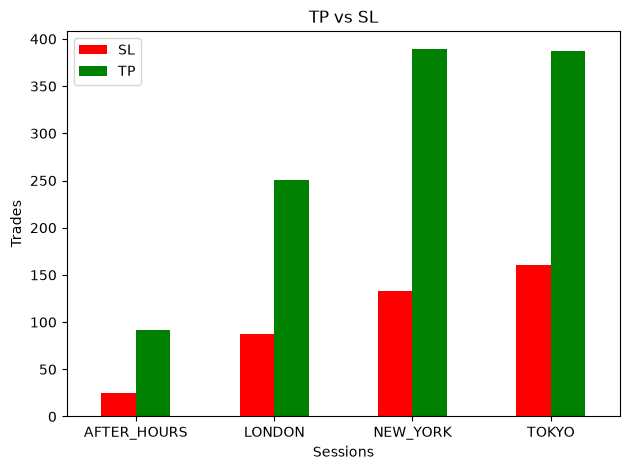

In [ ]:
# Session distribution
df_sessions_frame: DataFrame = df_raw.groupby(["session", "outcome_win"]).size().unstack(fill_value=0)
df_sessions_frame.columns = ["SL", "TP"]
df_sessions_frame.plot(kind="bar", color=["red", "green"])
print(df_sessions_frame)

plt.title("TP vs SL")
plt.xlabel("Sessions")
plt.ylabel("Trades")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Based on results, NEW_YORK session gives good results without additional SLs

rr_distribution
0.0 - 0.5    406
0.5 - 1.0    321
1.0 - 1.5    222
1.5 - 2.0    180
>= 2.0       396
dtype: int64


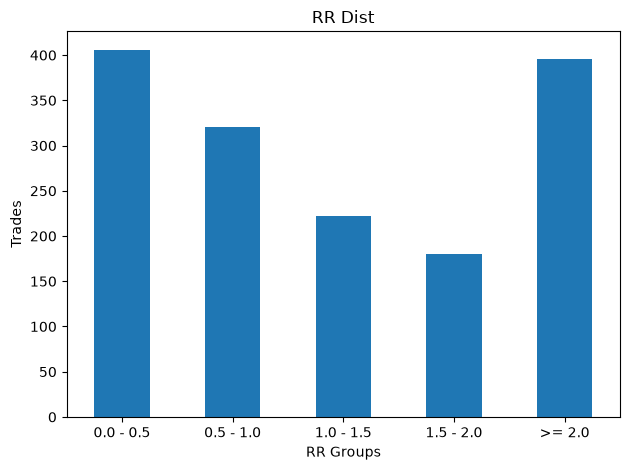

In [ ]:
# RR distribution
rr_distribution: Series[Any] = df_raw.groupby("rr_distribution").size()
print(rr_distribution)

rr_distribution.plot(kind="bar")

plt.title("RR Dist")
plt.xlabel("RR Groups")
plt.ylabel("Trades")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Based on results, min RR reached is 0.5